In [90]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import seaborn as sns

from scipy.stats import lognorm

from src.datasets import NonstationaryRewardDelayDataset

In [113]:
sns.set_theme(
    style="ticks",
    palette=sns.color_palette("mako", 1),
    rc={
        "axes.spines.right": False,
        "axes.spines.top": False,
        
        # Axes and line tickness
        'axes.linewidth': 3,
        "lines.linewidth": 2.5,
        
        # Tick thickness
        "xtick.major.width": 3,
        "ytick.major.width": 3,

        # Tick length
        "xtick.major.size": 7,
        "ytick.major.size": 7,
        
        # Font size
        "font.size": 16,
        "axes.labelsize": 16,
        "axes.titlesize": 16,
        "xtick.labelsize": 16,
        "ytick.labelsize": 16,
        "legend.fontsize": 16,
    }
)

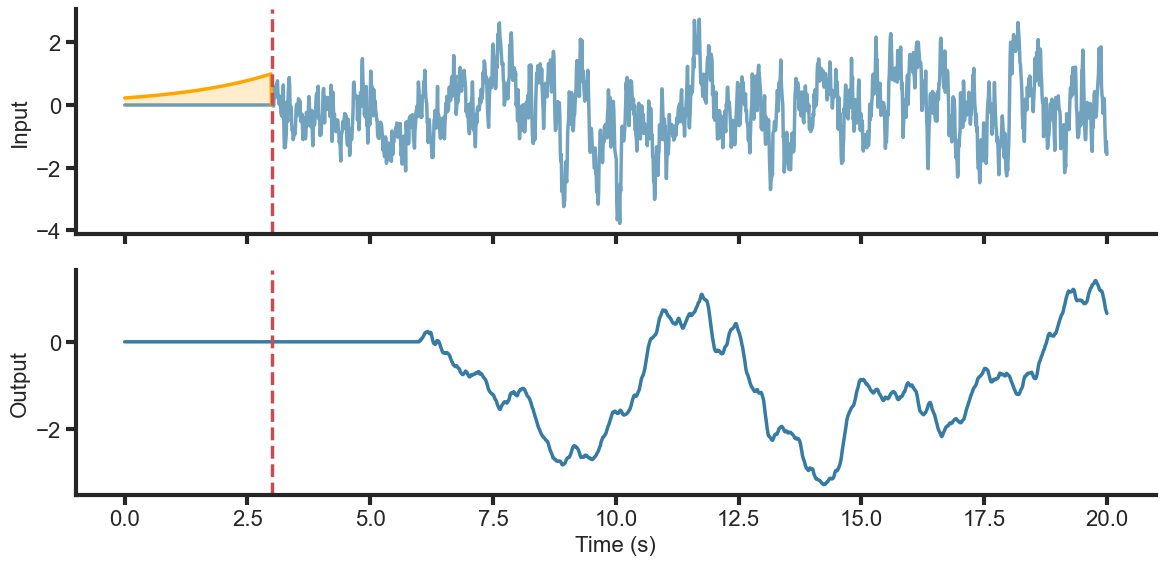

In [181]:
ktau=2

dataset = NonstationaryRewardDelayDataset(seed=1, kernel_tau=ktau, autocorr=0.9, noise_std=1, noise_mean=0, zero_integration=False)
inputs, outputs = dataset[0]

t = np.arange(len(inputs)) * dataset.dt

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

fontsize = 18
axes[0].tick_params()
axes[1].tick_params()

axes[0].plot(t, inputs[:, 0], alpha=0.7)

weights = np.exp(-np.arange(0, 3, dataset.dt) / ktau)
weights[0] = 0
kernel_t = np.arange(0,3,dataset.dt)
axes[0].plot(kernel_t, weights[::-1]+[0], color='orange')
axes[0].fill_between(kernel_t,weights[::-1],np.zeros(len(kernel_t)),color='orange',alpha=0.2)

axes[0].set_ylabel("Input")
axes[0].axvline(dataset.cue_onset * dataset.dt, color='r', linestyle='--', label='cue onset')
# axes[0].legend()

axes[1].plot(t, outputs)
axes[1].set_ylabel("Output")
axes[1].set_xlabel("Time (s)")
axes[1].axvline(dataset.cue_onset * dataset.dt, color='r', linestyle='--')

plt.tight_layout()
plt.show()

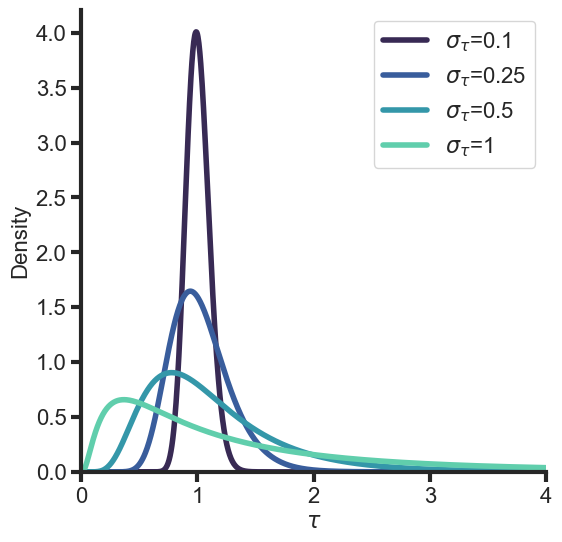

In [101]:
tau_mean1 = 0
tau_std1 = 1
hidden_size = 1000
etas = [0.1, 0.25, 0.5, 1]

plt.figure(figsize=(6, 6))

for eta in etas:
    # Sample
    dist = torch.exp(torch.normal(mean=tau_mean1, std=tau_std1, size=(hidden_size,)) * eta)
    data = dist.numpy()

    # True PDF params
    mu = eta * tau_mean1
    sigma = eta * tau_std1

    x = np.linspace(0, 4, 1000)
    pdf = lognorm(s=sigma, scale=np.exp(mu)).pdf(x)

    plt.plot(x, pdf, label=rf'$\sigma_\tau$={eta}')

plt.ylim(0)
plt.xlim(0, 4)
plt.xlabel(r'$\tau$')
plt.ylabel('Density')
plt.legend()